In [1]:
import numpy as np
import hoi
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

<img src="github_material.png" width="900">

# Tutorial 2
## From Variables to Interactions: Understanding Mental Health Data
- A Tutorial on Redundancy and Synergy in Mental Health–Related Variables


### Motivation

<img src="inside_out_emotions.png" width="500">

### Loading the data

In [2]:
df = pd.read_csv("Dataset_tutorial_3.csv")# Simulated dataset
print(df.head())
print(df.shape)

  name  stress  mood  sleep  fatigue  motivation  intrusive  help  social  \
0  Eve    10.0  43.0   71.0     36.0         9.0       43.0  77.0    49.0   
1  Eve    13.0  28.0   64.0     27.0        46.0       84.0  42.0    55.0   
2  Eve    13.0  28.0   64.0     27.0        46.0       84.0  42.0    55.0   
3  Eve    95.0  47.0   20.0     68.0        67.0       95.0  92.0   100.0   
4  Eve    31.0  58.0   29.0     67.0        46.0       20.0  37.0    25.0   

   organizing  feedback  evaluating  anxiety  enjoyment  learning  
0         4.0      69.0        32.0     76.0       51.0      13.0  
1         3.0      35.0        23.0     30.0       49.0      44.0  
2         3.0      35.0        23.0     30.0       49.0      44.0  
3       100.0      51.0        35.0      0.0       24.0      55.0  
4        54.0      27.0        28.0     82.0       40.0      43.0  
(5616, 15)


In [3]:
### How many subjects?
df["name"].nunique()

36

In [4]:
### How many measurments per subject?
df.groupby("name").size()

name
Aisha      156
Alice      156
Anika      156
Astrid     156
Bjorn      156
Bob        156
Charlie    156
Diana      156
Erik       156
Eve        156
Fatima     156
Frank      156
Freja      156
Grace      156
Hassan     156
Heidi      156
Hiroshi    156
Ingrid     156
Ivan       156
Judy       156
Karin      156
Lars       156
Layla      156
Li         156
Liv        156
Mei        156
Nils       156
Noor       156
Omar       156
Ravi       156
Saanvi     156
Sakura     156
Sven       156
Takumi     156
Yuki       156
Zain       156
dtype: int64

In [5]:
### variable names
feature_cols = [c for c in df.columns if c != "name"]
feature_cols

['stress',
 'mood',
 'sleep',
 'fatigue',
 'motivation',
 'intrusive',
 'help',
 'social',
 'organizing',
 'feedback',
 'evaluating',
 'anxiety',
 'enjoyment',
 'learning']

(156, 14)


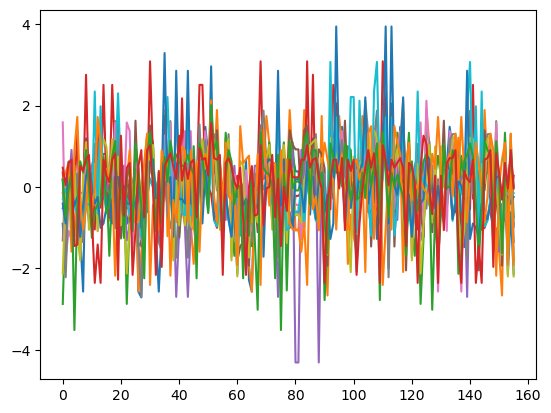

In [6]:
#### We'' check the data and dimensions
# loop for subject
for subject, subdf in df.groupby("name"):
    
    # matriz (time x variables)
    X = subdf[feature_cols].to_numpy(dtype=float)


    # normalization
    X = zscore(X, axis=0, nan_policy="omit")
    plt.plot(X)    
    print(np.shape(X))
    # NaN removal, if needed
    #X = X[np.isfinite(X).all(axis=1)]
    break

## Definition

The O-information is a multivariate measure of information capable of disentangling whether a subset of a variable `X` is dominated by redunancy or synergy. The O-information is defined as the difference between the Total Correlation and the Dual Total Correlation [1]. As both quantities are respectively linked to redundancy and synergy, the O-information is going to be positive when a system is dominated by redundant interactions and negative when the system is dominated by synergistic interactions. The mathematical definition of the O-information is given by:

$$
\Omega(X^{n})  =  TC(X^{n}) - DTC(X^{n}) \\
               =  (n - 2)H(X^{n}) + \sum_{j=1}^{n} \left[ H(X_{j}) - H(X_{-j}^{n}) \right]
$$

[1] Rosas FE, Mediano PAM, Gastpar M, Jensen HJ. Quantifying high-order interdependencies via multivariate extensions of the mutual information. Phys Rev E. 2019 Sep 13;100(3):032305. doi: 10.1103/PhysRevE.100.032305

[2] https://brainets.github.io/hoi/

In [7]:
# Oinfo = {}
# m = 3 #for triplets only

# # loop for subject
# for subject, subdf in df.groupby("name"):
    
#     # matriz (time x variables)
#     X = subdf[feature_cols].to_numpy(dtype=float)

#     # normalization
#     X = zscore(X, axis=0, nan_policy="omit")
#     print(np.shape(X))
#     # NaN removal, if needed
#     #X = X[np.isfinite(X).all(axis=1)]
#     model = hoi.metrics.Oinfo(X); ## (n_samples,n_features) #we already checked this above
#     result = model.fit(minsize=m, maxsize=m); ##Oinfo
#     Oinfo[subject] = result

#     #break


In [8]:
# np.save("Oinfo_mh.npy", Oinfo, allow_pickle=True)

In [9]:
Oinfo = np.load("Oinfo_mh.npy", allow_pickle=True).item()

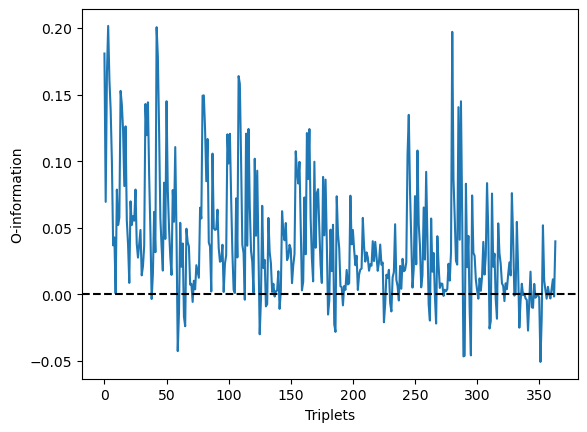

In [10]:
# Visualizing the O-information for all the triplets for the last subject 
plt.plot(Oinfo[subject])

# Add horizontal line at 0
plt.axhline(0, color='black', linestyle='--')

# Labels
plt.xlabel('Triplets')
plt.ylabel('O-information')

plt.show()

### Average values across subjects for each triplets

In [11]:
# Stack all subjects (subjects x triplets)
Oinfo_matrix = np.vstack([v.flatten() for v in Oinfo.values()])
print(np.shape(Oinfo_matrix))

# Mean across subjects
mean_oinfo = np.mean(Oinfo_matrix, axis=0)
print(np.shape(mean_oinfo))

(36, 364)
(364,)


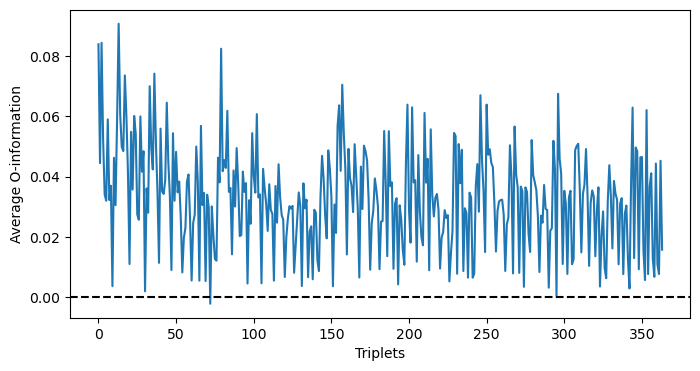

In [12]:
# Average O-information
plt.figure(figsize=(8,4))

plt.plot(mean_oinfo)

# Add horizontal line at 0
plt.axhline(0, color='black', linestyle='--')

# Labels
plt.xlabel('Triplets')
plt.ylabel('Average O-information')

plt.show()

## Top synergy and redundancy values across subjects

In [13]:
from itertools import combinations

# std and proportions of subjects for the top values
std_oinfo = np.std(Oinfo_matrix, axis=0)
prop_positive = np.mean(Oinfo_matrix > 0, axis=0)
prop_negative = np.mean(Oinfo_matrix < 0, axis=0)

# Triplet indices
m = 3
nplets = list(combinations(range(len(feature_cols)), m))

# Triplet names
triplet_names = [
    tuple(feature_cols[i] for i in triplet)
    for triplet in nplets
]

# Synergies: negative O-information
print("Synergistic triplets (negative O-information):")
for names, value, std, prop_neg in zip(triplet_names, mean_oinfo, std_oinfo, prop_negative):
    if value < 0:
        print(
            names,
            f"mean={value:.4f}",
            f"std={std:.4f}",
            f"prop_negative={prop_neg:.2f}"
        )

# Top 3 redundancies: highest positive O-information
positive_idx = np.where(mean_oinfo > 0)[0]
top3_idx = positive_idx[np.argsort(mean_oinfo[positive_idx])[-3:]][::-1]

print("\nTop 3 redundant triplets (highest positive O-information):")
for idx in top3_idx:
    print(
        triplet_names[idx],
        f"mean={mean_oinfo[idx]:.4f}",
        f"std={std_oinfo[idx]:.4f}",
        f"prop_positive={prop_positive[idx]:.2f}"
    )

Synergistic triplets (negative O-information):
('stress', 'evaluating', 'anxiety') mean=-0.0023 std=0.0109 prop_negative=0.61

Top 3 redundant triplets (highest positive O-information):
('stress', 'sleep', 'motivation') mean=0.0908 std=0.1346 prop_positive=0.83
('stress', 'mood', 'motivation') mean=0.0845 std=0.1284 prop_positive=0.94
('stress', 'mood', 'sleep') mean=0.0840 std=0.1129 prop_positive=0.83


## The top synergy and redundancy values per subject

In [14]:
for subject, values in Oinfo.items():
    
    values = np.squeeze(values)
    
    # Top redundancy (max)
    red_idx = np.argmax(values)
    red_triplet = tuple(feature_cols[i] for i in nplets[red_idx])
    
    # Top synergy (min)
    syn_idx = np.argmin(values)
    syn_triplet = tuple(feature_cols[i] for i in nplets[syn_idx])
    
    print(f"\nSubject: {subject}")
    print(f"  Top redundancy: {red_triplet} ({values[red_idx]:.4f})")
    print(f"  Top synergy:    {syn_triplet} ({values[syn_idx]:.4f})")


Subject: Aisha
  Top redundancy: ('stress', 'mood', 'intrusive') (0.2016)
  Top synergy:    ('organizing', 'anxiety', 'enjoyment') (-0.0506)

Subject: Alice
  Top redundancy: ('sleep', 'motivation', 'organizing') (0.1423)
  Top synergy:    ('mood', 'feedback', 'evaluating') (-0.1234)

Subject: Anika
  Top redundancy: ('mood', 'fatigue', 'intrusive') (0.1929)
  Top synergy:    ('stress', 'feedback', 'anxiety') (-0.0333)

Subject: Astrid
  Top redundancy: ('feedback', 'anxiety', 'enjoyment') (0.1346)
  Top synergy:    ('stress', 'fatigue', 'evaluating') (-0.0708)

Subject: Bjorn
  Top redundancy: ('mood', 'sleep', 'help') (0.1726)
  Top synergy:    ('motivation', 'help', 'social') (-0.1533)

Subject: Bob
  Top redundancy: ('motivation', 'intrusive', 'help') (0.3245)
  Top synergy:    ('stress', 'fatigue', 'motivation') (-0.0958)

Subject: Charlie
  Top redundancy: ('social', 'organizing', 'anxiety') (0.1505)
  Top synergy:    ('organizing', 'enjoyment', 'learning') (-0.0430)

Subject: D

### Visualizing the top values

In [15]:
subjects = list(Oinfo.keys())
n_features = len(feature_cols)

top_red_matrix = pd.DataFrame(0, index=subjects, columns=feature_cols)
top_syn_matrix = pd.DataFrame(0, index=subjects, columns=feature_cols)

for subject in subjects:
    
    values = np.squeeze(Oinfo[subject])
    
    # Top redundancy: maximum O-information
    red_idx = np.argmax(values)
    red_triplet = nplets[red_idx]
    
    # Top synergy: minimum O-information
    syn_idx = np.argmin(values)
    syn_triplet = nplets[syn_idx]
    
    # Mark variables in the top redundancy triplet
    for feature_idx in red_triplet:
        top_red_matrix.loc[subject, feature_cols[feature_idx]] = 1
    
    # Mark variables in the top synergy triplet
    for feature_idx in syn_triplet:
        top_syn_matrix.loc[subject, feature_cols[feature_idx]] = 1

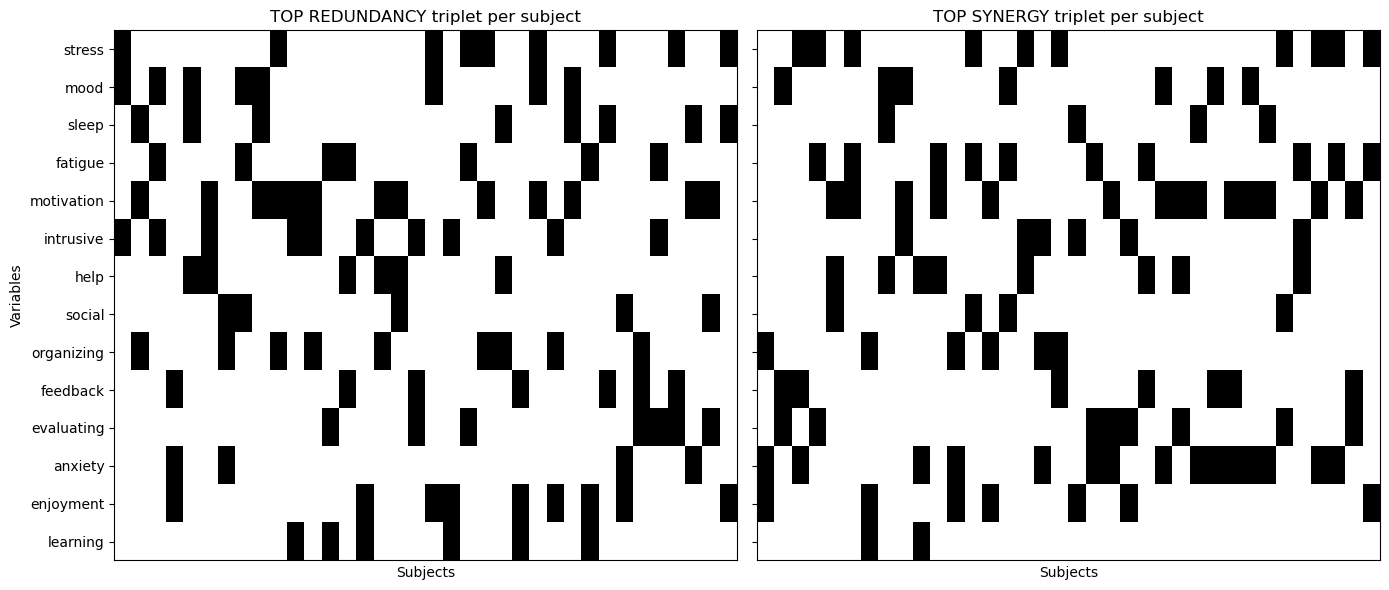

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Redundancy ---
im0 = axes[0].imshow(top_red_matrix.T, aspect='auto',cmap='gray_r')

axes[0].set_title('TOP REDUNDANCY triplet per subject')
axes[0].set_xlabel('Subjects')
axes[0].set_ylabel('Variables')

# Hide subject names (x-axis)
axes[0].set_xticks([])

# Show variable names (y-axis)
axes[0].set_yticks(range(len(feature_cols)))
axes[0].set_yticklabels(feature_cols)


# --- Synergy ---
im1 = axes[1].imshow(top_syn_matrix.T, aspect='auto',cmap='gray_r')

axes[1].set_title('TOP SYNERGY triplet per subject')
axes[1].set_xlabel('Subjects')

# Hide subject names
axes[1].set_xticks([])

# Y labels already shared


plt.tight_layout()
plt.show()

### Node-level (one variable) participation in redundant and synergistic interactions

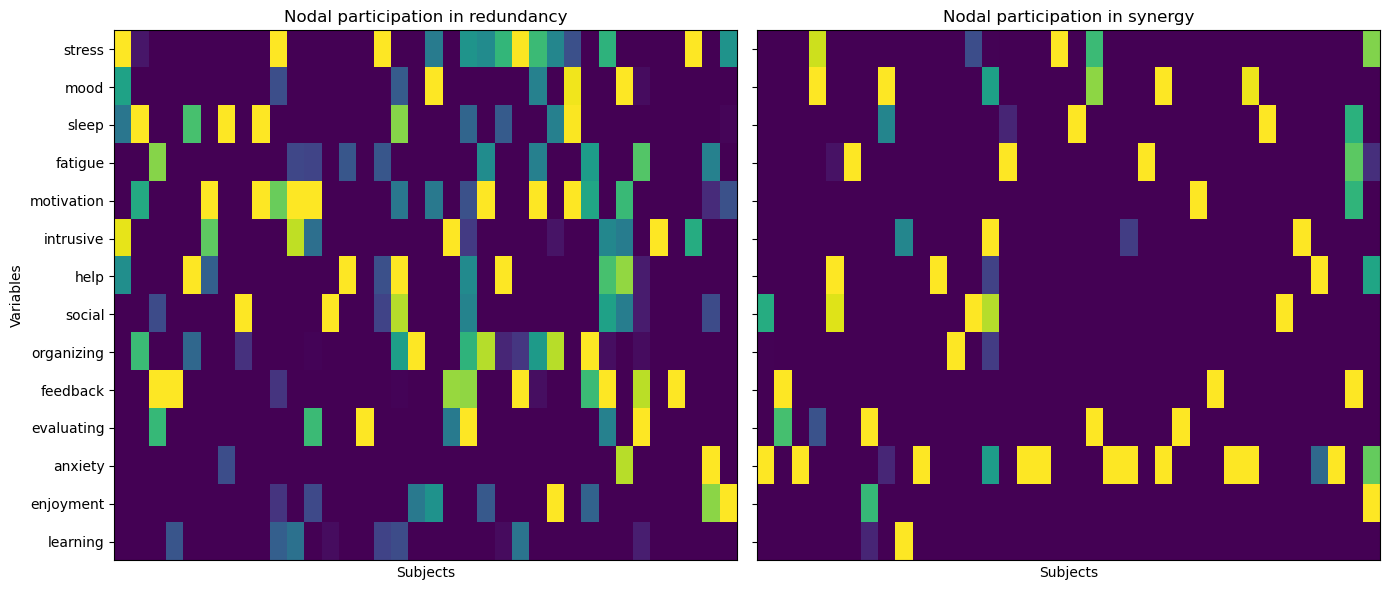

In [17]:
# Number of nodes/features
n_nodes = len(feature_cols)

# Triplets in the same order as Oinfo
nplets = np.array(nplets)

# Map each node to the triplets where it appears
node_to_triplets = [
    np.where(np.any(nplets == node, axis=1))[0]
    for node in range(n_nodes)
]

subjects = list(Oinfo.keys())

Red = []
Syn = []

for subject in subjects:
    
    values = np.squeeze(Oinfo[subject])
    
    # Separate redundancy and synergy
    red_vals = np.where(values > 0, values, 0)
    syn_vals = np.where(values < 0, -values, 0)  # absolute value
    
    # Node-level participation per subject
    red_node = [np.mean(red_vals[idx]) for idx in node_to_triplets]
    syn_node = [np.mean(syn_vals[idx]) for idx in node_to_triplets]
    
    Red.append(red_node)
    Syn.append(syn_node)

# Matrices: subjects x nodes
Red_matrix = pd.DataFrame(Red, index=subjects, columns=feature_cols)
Syn_matrix = pd.DataFrame(Syn, index=subjects, columns=feature_cols)


# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

Red_norm = Red_matrix.div(Red_matrix.max(axis=1).replace(0, np.nan), axis=0)
Syn_norm = Syn_matrix.div(Syn_matrix.max(axis=1).replace(0, np.nan), axis=0)

axes[0].imshow(Red_norm.T, aspect='auto',vmin=0.8,vmax=1)
axes[0].set_title('Nodal participation in redundancy')
axes[0].set_xlabel('Subjects')
axes[0].set_ylabel('Variables')
axes[0].set_xticks([])
axes[0].set_yticks(range(len(feature_cols)))
axes[0].set_yticklabels(feature_cols)

axes[1].imshow(Syn_norm.T, aspect='auto',vmin=0.8,vmax=1)
axes[1].set_title('Nodal participation in synergy')
axes[1].set_xlabel('Subjects')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()